# DATA 266 Assignment 4: Building a Mini GPT from Scratch

A GPT style decoder only Transformer built from `nn.Linear`, `nn.LayerNorm`, `nn.GELU` and
`nn.Embedding` only, trained on the character level Shakespeare corpus, then sampled with
greedy, temperature and top-k decoding.

No `nn.Transformer`, no `nn.MultiheadAttention`, no HuggingFace models.


In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(1337)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: mps


## Part 1 - Data Preparation

### 1.1 Character level tokenization

The vocabulary is the set of distinct characters in the corpus, so the mapping between text
and token ids is exact and invertible.


In [2]:
text = open("../data/shakespeare.txt", encoding="utf-8").read()

chars = sorted(set(text))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [char_to_idx[c] for c in s]
decode = lambda ids: "".join(idx_to_char[int(i)] for i in ids)

print("corpus length   :", len(text))
print("VOCABULARY SIZE :", vocab_size)
print("characters      :", repr("".join(chars)))

corpus length   : 1115394
VOCABULARY SIZE : 65
characters      : "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


### 1.2 Sliding window dataset

Sequence length 128. A window starting at position `t` gives input `[t ... t+127]` and
target `[t+1 ... t+128]`, so the target is the input shifted left by one and every position
is a next character prediction.


In [3]:
SEQ_LEN = 128
STRIDE = 32          # window step


class CharDataset(Dataset):
    def __init__(self, data, seq_len=SEQ_LEN, stride=STRIDE):
        self.data, self.seq_len, self.stride = data, seq_len, stride
        self.n = (len(data) - seq_len - 1) // stride + 1

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        s = i * self.stride
        return self.data[s : s + self.seq_len], self.data[s + 1 : s + 1 + self.seq_len]


data = torch.tensor(encode(text), dtype=torch.long)
dataset = CharDataset(data)
print("windows:", len(dataset))

windows: 34853


In [4]:
# Two example input-target pairs, decoded back to text.
for i in [0, 500]:
    x, y = dataset[i]
    print(f"window {i}")
    print("input  :", repr(decode(x[:70])))
    print("target :", repr(decode(y[:70])))
    print()

window 0
input  : 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpe'
target : 'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpea'

window 500
input  : "I hear hither your husband's drum,\nSee him pluck Aufidius down by the "
target : " hear hither your husband's drum,\nSee him pluck Aufidius down by the h"



## Part 2 - GPT Architecture

### 2.1 Multi-head masked self attention

Queries, keys and values come from separate linear projections. The model dimension is split
into `n_heads` slices and all heads are computed in parallel with one batched matmul. Scores
are scaled by the square root of the head dimension to keep the softmax out of its saturated
regime.

The causal mask is applied to the **scores**, before the softmax, so position `i` can only
attend to positions `<= i`. Masking after the softmax would leave the rows not summing to 1.


In [5]:
class MultiHeadMaskedSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_len):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.register_buffer("mask", torch.tril(torch.ones(max_len, max_len)))

    def forward(self, x):
        B, T, D = x.shape
        # (B, T, D) -> (B, n_heads, T, d_head)
        split = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float("-inf"))
        attn = torch.softmax(scores, dim=-1)

        out = (attn @ v).transpose(1, 2).reshape(B, T, D)   # concatenate heads
        return self.W_o(out)

### 2.2 Decoder block

Multi-head attention, residual, LayerNorm, then feedforward (`Linear -> GELU -> Linear`),
residual, LayerNorm.


In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, max_len):
        super().__init__()
        self.attn = MultiHeadMaskedSelfAttention(d_model, n_heads, max_len)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model))
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.ln1(x + self.attn(x))
        x = self.ln2(x + self.ff(x))
        return x

### 2.3 The GPT model

Token embedding + learnable positional embedding, a stack of decoder blocks, and a final
linear projection to vocabulary logits. The positional embedding is needed because self
attention on its own is permutation equivariant.


In [7]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=4,
                 d_ff=1024, max_len=SEQ_LEN):
        super().__init__()
        self.max_len = max_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList(
            [DecoderBlock(d_model, n_heads, d_ff, max_len) for _ in range(n_layers)])
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, idx):
        T = idx.size(1)
        x = self.token_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        for block in self.blocks:
            x = block(x)
        return self.lm_head(x)


D_MODEL, N_HEADS, N_LAYERS = 256, 4, 4

model = MiniGPT(vocab_size, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS).to(device)

print("Total parameter count :", sum(p.numel() for p in model.parameters()))
print("Hidden dimension      :", D_MODEL)
print("Number of heads       :", N_HEADS)
print("Number of layers      :", N_LAYERS)

Total parameter count : 3225153
Hidden dimension      : 256
Number of heads       : 4
Number of layers      : 4


## Part 3 - Training

Adam at a learning rate of 1e-3, batch size 64, 6 epochs.


In [8]:
BATCH_SIZE, EPOCHS, LR = 64, 6, 1e-3

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

epoch_losses = []
for epoch in range(1, EPOCHS + 1):
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()
        n += 1

    epoch_losses.append(total / n)
    print(f"epoch {epoch}/{EPOCHS}  loss {epoch_losses[-1]:.4f}")

epoch 1/6  loss 1.8955


epoch 2/6  loss 1.3892


epoch 3/6  loss 1.2651


epoch 4/6  loss 1.1829


epoch 5/6  loss 1.1064


epoch 6/6  loss 1.0272


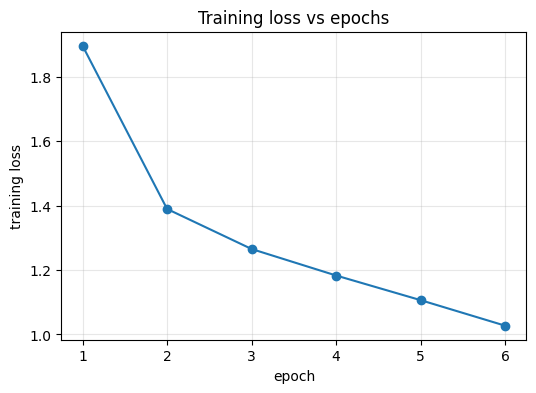

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), epoch_losses, "o-")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Training loss vs epochs")
plt.grid(alpha=0.3)
plt.savefig("../data/training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 4 - Sampling

One generation loop shared by all three strategies. At each step the model runs on the last
128 tokens, the logits at the final position are turned into a choice by the strategy, and
the chosen character is appended.


In [10]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=300, strategy="greedy", temperature=1.0, top_k=None):
    model.eval()
    idx = torch.tensor([encode(prompt)], device=device)

    for _ in range(max_new_tokens):
        logits = model(idx[:, -model.max_len:])[:, -1, :]      # last position only

        if strategy == "greedy":
            next_id = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if strategy == "top_k":
                kth = torch.topk(logits, top_k, dim=-1).values[:, -1:]
                logits = logits.masked_fill(logits < kth, float("-inf"))
            next_id = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)

        idx = torch.cat([idx, next_id], dim=1)

    return decode(idx[0].tolist())


PROMPT = "ROMEO:"

### 4.1 Greedy decoding

Take the most likely character at every step. Deterministic.


In [11]:
print(generate(model, PROMPT, strategy="greedy"))

ROMEO:
I am sorry and the wisest course of the world,
That we shall have seen them against the world.

ROMEO:
And what then it is the matter for his courtesy.

JULIET:
Ay, by this manner of my brother's head.

ROMEO:
And that he shall not see to be so fould think
In this best and be brief. The man that he


### 4.2 Temperature sampling

Sample from `softmax(logits / T)`. `T < 1` sharpens the distribution toward the most likely
character, `T > 1` flattens it toward uniform.


In [12]:
for T in [0.5, 1.0, 1.5]:
    print(f"temperature = {T}")
    torch.manual_seed(0)
    print(generate(model, PROMPT, strategy="temperature", temperature=T))
    print()

temperature = 0.5


ROMEO:
Must he died on the way, and the rest,
Yet I will not see the prince to do
Our death-head. He will be so entreat you.

LUCIO:
A great part gentle confess you fly to send the gracious by
a brawling of the beak for me to set it off,
but not for the mean to death, and to see him hence:
but his for his

temperature = 1.0


ROMEO:
Must I love you, sir.

PETER:
How soon my friends it nor side; I will not.

POLIPEY:
Let us, my lord. You have for you our holy office.
Camillo for thee, cornful wars, it shall be at none.
They say, they not this wealth usurps to bear
A forefaneful vouched orable for such faults'
lother becomes his

temperature = 1.5


ROMEO:
Must I? Say you, sHe'll bury droans
Ppeer Dian-but the rest, or bous aniel
gone, ay eagle: Him royal can eye's for you counsel; over you have
Kather condemnandly keeps, bush you and you would
Will dart you thrither sligg. Nimplips on either:
Jointice, am inoriviable; strokes--lean!---O: Mine
It wil



### 4.3 Top-k sampling

Keep only the `k` most likely characters, set the rest to `-inf`, and sample from the
renormalised distribution. Temperature is held at 1.0 so the only variable is `k`.


In [13]:
for k in [2, 40]:
    print(f"top-k, k = {k}")
    torch.manual_seed(0)
    print(generate(model, PROMPT, strategy="top_k", top_k=k))
    print()

top-k, k = 2


ROMEO:
If they say 'nointed.' 'He killed him,'
'Here is a charment to the sea,
'Twas 'tis the farthe that would be done
To see a prophecation.' Ang bold with the senation
To be an angry angry angry and man of my brattle.
The sentences have been the damned bodies;
And when they shall be thou stay'd with th

top-k, k = 40


ROMEO:
Must I love you, sir.

PETER:
How soon my friends it nor side; I will not.

POLIPEY:
Let us, my lord. You have for you our holy office.
Camillo for thee, cornful wars, it shall be at none.
They say, they not this wealth usurps to bear
A forefaneful vouched orable for such faults'
lother becomes his



## Part 5 - Analysis

To compare the strategies on more than one sample, each setting is scored on two measures,
averaged over 3 generations:

* **valid word rate** - fraction of words that occur in the corpus. A character level model
  has to spell for itself, so this measures **coherence**.
* **distinct-3** - fraction of character trigrams that are unique. This measures
  **diversity**: a low value means the text repeats itself.


In [14]:
corpus_words = set(w.strip(".,;:!?'\"-").lower() for w in text.split())

settings = [("greedy",          dict(strategy="greedy")),
            ("temperature 0.5", dict(strategy="temperature", temperature=0.5)),
            ("temperature 1.0", dict(strategy="temperature", temperature=1.0)),
            ("temperature 1.5", dict(strategy="temperature", temperature=1.5)),
            ("top-k k=2",       dict(strategy="top_k", top_k=2)),
            ("top-k k=40",      dict(strategy="top_k", top_k=40))]

print(f"{'decoding':<16} {'valid words':>12} {'distinct-3':>11}")
for name, kwargs in settings:
    valid, distinct = [], []
    for seed in range(3):
        torch.manual_seed(seed)
        s = generate(model, PROMPT, **kwargs)[len(PROMPT):]
        words = [w.strip(".,;:!?'\"-").lower() for w in s.split()]
        words = [w for w in words if w]
        valid.append(sum(w in corpus_words for w in words) / len(words))
        tri = [s[i:i + 3] for i in range(len(s) - 2)]
        distinct.append(len(set(tri)) / len(tri))
    print(f"{name:<16} {sum(valid) / 3:>12.3f} {sum(distinct) / 3:>11.3f}")

decoding          valid words  distinct-3


greedy                  0.984       0.671


temperature 0.5         0.984       0.753


temperature 1.0         0.864       0.864


temperature 1.5         0.755       0.905


top-k k=2               0.932       0.746


top-k k=40              0.869       0.859


| decoding | valid words (coherence) | distinct-3 (diversity) |
|---|---|---|
| greedy | **0.984** | 0.671 |
| temperature 0.5 | **0.984** | 0.753 |
| temperature 1.0 | 0.864 | 0.864 |
| temperature 1.5 | 0.755 | **0.905** |
| top-k k=2 | 0.932 | 0.746 |
| top-k k=40 | 0.869 | 0.859 |

**Greedy** takes the argmax at every step, so it is deterministic - the three "samples" it
contributes to the average are the same string. It scores the joint best valid word rate
(0.984) and by a wide margin the worst diversity (0.671, the lowest of all six settings).
The failure mode is visible in the sample: *"the wisest course of the world, / That we shall
have seen them against the world"* circles back to the same phrase, because with no
randomness the model cannot leave a high probability region once it enters one.

**Temperature** divides the logits by `T` before the softmax. The three settings are monotone
in both measures: as `T` rises from 0.5 to 1.5 the valid word rate falls (0.984, 0.864, 0.755)
and diversity rises (0.753, 0.864, 0.905). `T = 0.5` stays near the mode and spells almost as
well as greedy while still varying between runs; `T = 1.5` flattens the distribution enough
that unlikely characters are picked regularly, giving invented words like *droans*, *sligg*
and *inoriviable*, and roughly one word in four is not a real one.

**Top-k** keeps the `k` most likely characters and renormalises, deleting the tail instead of
reshaping the whole distribution. `k = 2` is clearly more coherent than `k = 40` (0.932 vs
0.869) and clearly less diverse (0.746 vs 0.859) - a gap of 0.113 in diversity, so the knob
does real work in this range. At `k = 2` the model is choosing between only two characters at
each step and starts to lock on, producing *"angry angry angry"*.

Note that `k = 40` produced output **byte identical** to `T = 1.0`: with only 65 characters in
the vocabulary, the 25 lowest ranked ones carry too little probability to ever be sampled, so
truncating them changes nothing. Top-k only does real work when `k` is small relative to the
number of characters the model is actually considering - on a sub-word vocabulary of 50,000
tokens that would almost always be the case.

**Most coherent: greedy.** It ties with `T = 0.5` on valid word rate (0.984 each), but it is
the more conservative of the two: it only ever emits the character the model is most confident
about, and its diversity score is the lowest of any setting (0.671). That is the trade - the
same conservatism that keeps it spelling correctly is what makes it deterministic and
repetitive, so `T = 0.5` (0.984 coherence at 0.753 diversity) is the better practical choice
when any variety is wanted.

**Most diverse: temperature 1.5**, with the highest distinct-3 (0.905), clear of every other
setting. That diversity is bought with the worst coherence (0.755) - about one word in four is
invented.

Overall, decoding trades coherence against diversity, and the two knobs do it differently:
temperature rescales the entire distribution, while top-k truncates its tail and leaves the
head untouched.
